In [1]:
import os
os.chdir('../..')

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from utils.load_datasets import MaterialsProjectLoader

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-07 12:44:50.440 | SUCCESS  | utils.load_datasets:_load_api_key:352 - Successfully loaded Materials Project API key
2026-02-07 12:44:50.441 | INFO     | utils.load_datasets:load_data:373 - Found existing cleaned dataset at data/Materials Project/stable_oxides.csv. Loading...


In [ ]:
mp = MaterialsProjectLoader()
df = mp.load_data()

In [3]:
df

formula_pretty,material_id,energy_per_atom,formation_energy_per_atom,crystal_system,space_group,a,b,c,alpha,beta,gamma,volume
str,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64
"""FeO""","""mp-cunat""",-8.19051,-1.481519,"""Monoclinic""","""C2/m""",3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477
"""PbO""","""mp-bdmf""",-5.800276,-1.469972,"""Tetragonal""","""P4/nmm""",3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627
"""SnO""","""mp-dcr""",-6.108469,-1.629702,"""Tetragonal""","""P4/nmm""",3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593
"""PdO""","""mp-bzk""",-5.853748,-0.789826,"""Tetragonal""","""P4_2/mmc""",3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274
"""CuO""","""mp-cnc""",-5.466379,-0.942795,"""Tetragonal""","""P4_2/mmc""",2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449
…,…,…,…,…,…,…,…,…,…,…,…,…
"""FeH4(ClO)2""","""mp-bjim""",-5.265791,-1.305381,"""Monoclinic""","""C2/m""",5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118
"""MnH4(BrO)2""","""mp-bjsb""",-5.299537,-1.309259,"""Monoclinic""","""C2/m""",3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532
"""MgH4(ClO)2""","""mp-bkaa""",-4.830206,-1.629746,"""Monoclinic""","""C2/m""",3.703055,5.847166,5.847166,92.982577,100.299353,100.299353,122.095654


# Plots for investegating

In [4]:
def plot_materials_data(df: pl.DataFrame):
    """
    Generates plots for Materials Project data using a Polars DataFrame.
    """
    logger.info("Starting visualization of Materials Project data...")

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    logger.info("Generating Crystal System distribution plot...")
    crystal_counts = (
        df.group_by("crystal_system")
        .len()
        .sort("len", descending=True)
    )

    sns.barplot(
        ax=axes[0],
        x=crystal_counts["crystal_system"].to_list(),
        y=crystal_counts["len"].to_list(),
    )

    axes[0].set_title("Materials Project: Diversity of Crystal Systems", fontsize=14)
    axes[0].set_xlabel("Crystal System", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)

    logger.info("Generating Stability Landscape scatter plot...")
    sns.scatterplot(
        ax=axes[1],
        data=df.to_pandas(), 
        x='formation_energy_per_atom', 
        y='energy_per_atom', 
        hue='crystal_system', 
        palette="viridis", 
        s=50, 
        alpha=0.7
    )
    axes[1].set_title("Materials Project: Stability Landscape (Oxides)", fontsize=14)
    axes[1].set_xlabel("Formation Energy (eV/atom)", fontsize=12)
    axes[1].set_ylabel("Energy per Atom (eV/atom)", fontsize=12)
    axes[1].legend(title="Symmetry", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    logger.info("Generating Volume Distribution plot...")
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df.to_pandas(), 
        x='volume', 
        hue='crystal_system', 
        fill=True, 
        common_norm=False, 
        alpha=0.3
    )
    plt.title("Materials Project: Lattice Volume Distribution by Crystal System", fontsize=14)
    plt.xlabel("Lattice Volume (Å³)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.show()

    logger.success("Visualization complete.")

2026-02-07 12:44:50.499 | INFO     | __main__:plot_materials_data:5 - Starting visualization of Materials Project data...
2026-02-07 12:44:50.524 | INFO     | __main__:plot_materials_data:10 - Generating Crystal System distribution plot...
2026-02-07 12:44:50.591 | INFO     | __main__:plot_materials_data:28 - Generating Stability Landscape scatter plot...


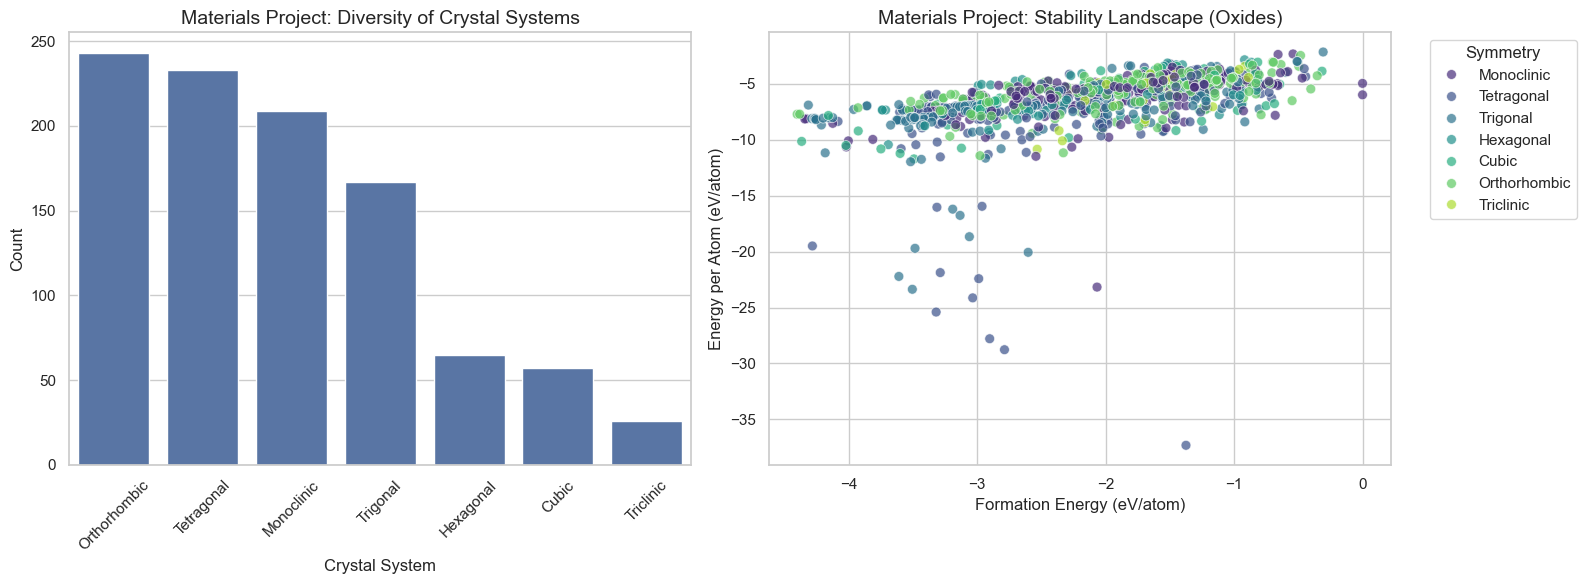

2026-02-07 12:44:50.711 | INFO     | __main__:plot_materials_data:47 - Generating Volume Distribution plot...


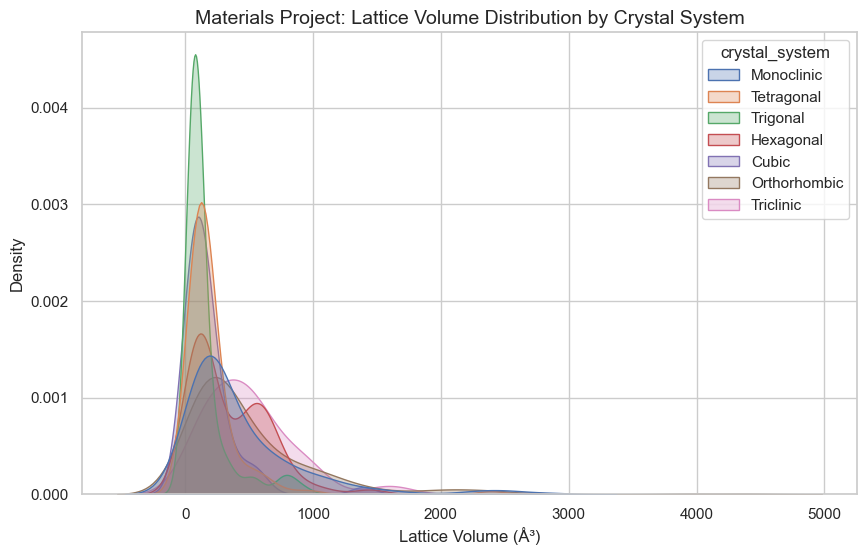

2026-02-07 12:44:50.778 | SUCCESS  | __main__:plot_materials_data:62 - Visualization complete.


In [5]:
plot_materials_data(df)